In [29]:
# appendix A Introduction to PyTorch
# ===================================

In [30]:
import torch
torch.__version__

'2.4.0+cpu'

In [31]:
torch.cuda.is_available()

False

In [32]:
# test pytorch setup using
# https://github.com/rasbt/stat453-deep-learning-ss21/blob/main/L08/code/cross-entropy-pytorch.ipynb

In [33]:
# Onehot Encoding

def to_onehot(y, num_classes):
    y_onehot = torch.zeros(y.size(0), num_classes)
    y_onehot.scatter_(1, y.view(-1, 1).long(), 1).float()
    return y_onehot

y = torch.tensor([0, 1, 2, 2])

y_enc = to_onehot(y, 3)

print('one-hot encoding:\n', y_enc)



one-hot encoding:
 tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.]])


In [34]:
# softmax

Z = torch.tensor( [[-0.3,  -0.5, -0.5],
                   [-0.4,  -0.1, -0.5],
                   [-0.3,  -0.94, -0.5],
                   [-0.99, -0.88, -0.5]])

Z

tensor([[-0.3000, -0.5000, -0.5000],
        [-0.4000, -0.1000, -0.5000],
        [-0.3000, -0.9400, -0.5000],
        [-0.9900, -0.8800, -0.5000]])

In [35]:
def softmax(z):
    return (torch.exp(z.t()) / torch.sum(torch.exp(z), dim=1)).t()

smax = softmax(Z)
print('softmax:\n', smax)

softmax:
 tensor([[0.3792, 0.3104, 0.3104],
        [0.3072, 0.4147, 0.2780],
        [0.4263, 0.2248, 0.3490],
        [0.2668, 0.2978, 0.4354]])


In [36]:
def to_classlabel(z):
    return torch.argmax(z, dim=1)

print('predicted class labels: ', to_classlabel(smax))
print('true class labels: ', to_classlabel(y_enc))

predicted class labels:  tensor([0, 1, 0, 2])
true class labels:  tensor([0, 1, 2, 2])


In [37]:
# cross enthropy

def cross_entropy(softmax, y_target):
    return - torch.sum(torch.log(softmax) * (y_target), dim=1)

xent = cross_entropy(smax, y_enc)
print('Cross Entropy:', xent)

Cross Entropy: tensor([0.9698, 0.8801, 1.0527, 0.8314])


In [38]:
import torch.nn.functional as F

In [39]:
F.nll_loss(torch.log(smax), y, reduction='none')

tensor([0.9698, 0.8801, 1.0527, 0.8314])

In [40]:
F.cross_entropy(Z, y, reduction='none')

tensor([0.9698, 0.8801, 1.0527, 0.8314])

In [41]:
# defaults

F.cross_entropy(Z, y)

tensor(0.9335)

In [42]:
torch.mean(cross_entropy(smax, y_enc))

tensor(0.9335)

In [43]:
# Listing A.1 Creating PyTorch tensors 
# ------------------------------------

import torch

tensor0d = torch.tensor(1)

tensor1d = torch.tensor([1, 2, 3])

tensor2d = torch.tensor([[1, 2], 
                         [3, 4]])

tensor3d = torch.tensor([[[1, 2], [3, 4]], 
                         [[5, 6], [7, 8]]])


In [44]:
# A.2.2 Tensor data types
# -----------------------
tensor1d = torch.tensor([1, 2, 3])
print(tensor1d.dtype)

torch.int64


In [45]:
floatvec = torch.tensor([1.0, 2.0, 3.0])
print(floatvec.dtype)

torch.float32


In [46]:
floatvec = tensor1d.to(torch.float32)
print(floatvec.dtype)

torch.float32


In [47]:
# A.2.3 Common PyTorch tensor operations
# --------------------------------------

tensor2d = torch.tensor([[1, 2, 3], 
                         [4, 5, 6]])
print(tensor2d)

tensor([[1, 2, 3],
        [4, 5, 6]])


In [48]:
print(tensor2d.shape)

torch.Size([2, 3])


In [49]:
print(tensor2d.reshape(3, 2))

tensor([[1, 2],
        [3, 4],
        [5, 6]])


In [50]:
print(tensor2d.view(3, 2))

tensor([[1, 2],
        [3, 4],
        [5, 6]])


In [51]:
print(tensor2d.T)

tensor([[1, 4],
        [2, 5],
        [3, 6]])


In [52]:
print(tensor2d.matmul(tensor2d.T))

tensor([[14, 32],
        [32, 77]])


In [53]:
print(tensor2d @ tensor2d.T)

tensor([[14, 32],
        [32, 77]])


In [54]:
# Listing A.2 A logistic regression forward pass
# ----------------------------------------------

import torch.nn.functional as F

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2])
b = torch.tensor([0.0])
z = x1 * w1 + b
a = torch.sigmoid(z)
loss = F.binary_cross_entropy(a, y)

In [55]:
# 10/27/24 - stop reading Appendix at Figure A.8

In [56]:
# 2.2 Tokenizing text
# -------------------

# download "the-verdict.txt" to drive
import urllib.request
url = ("https://raw.githubusercontent.com/rasbt/"
       "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
       "the-verdict.txt")
file_path = "E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\the-verdict.txt"
urllib.request.urlretrieve(url, file_path)



('E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\the-verdict.txt',
 <http.client.HTTPMessage at 0x145bfad4fd0>)

In [57]:
# load the the-verdict.txt file 

with open("E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
print("Total number of character:", len(raw_text))
print(raw_text[:99])


Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [58]:
# split a text on whitespace characters

import re
text = "Hello, world. This, is a test."
result = re.split(r'(\s)', text)
print(result)

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


In [59]:
# modify the regular expression splits on whitespaces (\s), commas, and periods ([,.])

result = re.split(r'([,.]|\s)', text)
print(result)

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


In [60]:
#  can remove white space characters safely as follows

result = [item for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']


In [61]:
# modify it a bit further so that it can also handle other types of punctuation, such as question marks, quotation marks,
# and the double-dashes we have seen earlier in the first 100 characters of Edith Wharton’s short story, along with additional special characters:

text = "Hello, world. Is this-- a test?"
result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [item.strip() for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


In [62]:
# apply tokenizer to Edith Wharton’s entire short story:

preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(len(preprocessed))

4690


In [63]:
# print the first 30 tokens for a quick visual check:

print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


In [64]:
# create a list of all unique tokens and sort them alphabetically to determine the vocabulary size

all_words = sorted(set(preprocessed))
vocab_size = len(all_words)
print(vocab_size)

1130


In [65]:
# create the vocabulary and print its first 51 entries for illustration purposes

vocab = {token:integer for integer,token in enumerate(all_words)}
for i, item in enumerate(vocab.items()):
    print(item)
    if i >= 50:
        break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon', 37)
('Gisburn', 38)
('Gisburns', 39)
('Grafton', 40)
('Greek', 41)
('Grindle', 42)
('Grindles', 43)
('HAD', 44)
('Had', 45)
('Hang', 46)
('Has', 47)
('He', 48)
('Her', 49)
('Hermia', 50)


In [66]:
# Listing 2.3 Implementing a simple text tokenizer

class SimpleTokenizerV1:
    def __init__(self, vocab):
        # Stores the vocabulary as a class attribute for access in the encode and decode methods
        self.str_to_int = vocab
        # Creates an inverse vocabulary that maps token IDs back to the original text tokens
        self.int_to_str = {i:s for s,i in vocab.items()}
        
    # Processes input text into token IDs
    def encode(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    # Converts token IDs back into text
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        
        # Removes spaces before the specified punctuation
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

In [67]:
# instantiate a new tokenizer object from the SimpleTokenizerV1 class and tokenize a passage from Edith Wharton’s short story

tokenizer = SimpleTokenizerV1(vocab)
text = """"It's the last he painted, you know," 
       Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [68]:
# turn these token IDs back into text using the decode method

print(tokenizer.decode(ids))

" It' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.


In [69]:
# apply it to a new text sample not contained in the training set

text = "Hello, do you like tea?"
print(tokenizer.encode(text))

KeyError: 'Hello'

In [70]:
# modify the vocabulary to include these two special tokens, <unk> and <|endoftext|>, by adding them to our list of all unique words

all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = {token:integer for integer,token in enumerate(all_tokens)}

print(len(vocab.items()))

1132


In [71]:
# As an additional quick check, let’s print the last five entries of the updated vocabulary

for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


In [72]:
# adjust the tokenizer 

class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = { i:s for s,i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        # Replaces unknown words by <|unk|> tokens
        preprocessed = [item if item in self.str_to_int
                        else "<|unk|>" for item in preprocessed]

        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        
        # Replaces spaces before the specified punctuations
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
        return text

In [73]:
# try this new tokenizer out in practice. For this, we will use a simple text sample that we concatenate from two independent and unrelated sentences

text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
text = " <|endoftext|> ".join((text1, text2))
print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [74]:
# tokenize the sample text using the SimpleTokenizerV2 on the vocab we previously created

tokenizer = SimpleTokenizerV2(vocab)
print(tokenizer.encode(text))

[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131, 7]


In [75]:
#  detokenize the text for a quick sanity check

print(tokenizer.decode(tokenizer.encode(text)))

<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.


In [76]:
# 2.5 Byte pair encoding
# ======================

In [77]:
#!pip install tiktoken

In [78]:
# check the version you currently have installed

from importlib.metadata import version
import tiktoken
print("tiktoken version:", version("tiktoken"))

tiktoken version: 0.7.0


In [79]:
# instantiate the BPE tokenizer from tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

In [80]:
# usage of this tokenizer is similar to the SimpleTokenizerV2

text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


In [81]:
# convert the token IDs back into text using the decode method

strings = tokenizer.decode(integers)
print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


In [82]:
# Exercise 2.1 Byte pair encoding of unknown words

text = (
    "Akwirw ier"
)
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(integers)


[33901, 86, 343, 86, 220, 959]


In [83]:
strings = tokenizer.decode(integers)
print(strings)

Akwirw ier


In [84]:
# 2.6 Data sampling with a sliding window
# ======================================== 

In [85]:
#  tokenize the whole “The Verdict” short story using the BPE tokenizer

with open("E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
    
enc_text = tokenizer.encode(raw_text)
print(len(enc_text))


5145


In [86]:
#  remove the first 50 tokens from the dataset for demonstration purposes, as it results in a slightly more interesting text passage in the next steps

enc_sample = enc_text[50:]

In [87]:
# One of the easiest and most intuitive ways to create the input–target pairs for the next-word prediction task is to create two variables, x and y, 
# where x contains the input tokens and y contains the targets, which are the inputs shifted by 1

context_size = 4
x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]
print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [88]:
# By processing the inputs along with the targets, which are the inputs shifted by one position, we can create the next-word prediction tasks

for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(context, "---->", desired)

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257


In [89]:
# repeat the previous code but convert the token IDs into text

for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


In [90]:
# For the efficient data loader implementation, we will use PyTorch’s built-in Dataset and DataLoader classes. 

# Listing 2.5 A dataset for batched inputs and targets

import torch
from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenizes the entire text
        token_ids = tokenizer.encode(txt)

        # Uses a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    # Returns the total number of rows in the dataset
    def __len__(self):
        return len(self.input_ids)

    # Returns a single row from the dataset
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [91]:
# Listing A.5 Creating a small toy dataset 
# ========================================

In [92]:
X_train = torch.tensor([
    [-1.2, 3.1],
    [-0.9, 2.9],
    [-0.5, 2.6],
    [2.3, -1.1],
    [2.7, -1.5]
])
y_train = torch.tensor([0, 0, 0, 1, 1])

X_test = torch.tensor([
    [-0.8, 2.8],
    [2.6, -1.6],
])
y_test = torch.tensor([0, 1])

In [93]:
# Listing A.6 Defining a custom Dataset class
# ===========================================

In [94]:
from torch.utils.data import Dataset

class ToyDataset(Dataset):
    def __init__(self, X, y):
        self.features = X
        self.labels = y

    # Instructions for retrieving exactly one data record and the corresponding label
    def __getitem__(self, index):
        one_x = self.features[index]
        one_y = self.labels[index]
        return one_x, one_y

    def __len__(self):
        # Instructions for returning the total length of the dataset
        return self.labels.shape[0]

train_ds = ToyDataset(X_train, y_train)
test_ds = ToyDataset(X_test, y_test)

In [95]:
# we have five rows, which we can double-check

print(len(train_ds))

5


In [96]:
# use PyTorch’s DataLoader class to sample from it

from torch.utils.data import DataLoader


torch.manual_seed(123)

train_loader = DataLoader(
    # The ToyDataset instance created earlier serves as input to the data loader.
    dataset=train_ds,
    batch_size=2,
    # Whether or not to shuffle the data
    shuffle=True,
    # The number of background processes
    num_workers=0
)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=2,
    # It is not necessary to shuffle a test dataset.
    shuffle=False,
    num_workers=0
)

In [97]:
# After instantiating the training data loader, we can iterate over it. 

for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}:", x, y)

Batch 1: tensor([[ 2.3000, -1.1000],
        [-0.9000,  2.9000]]) tensor([1, 0])
Batch 2: tensor([[-1.2000,  3.1000],
        [-0.5000,  2.6000]]) tensor([0, 0])
Batch 3: tensor([[ 2.7000, -1.5000]]) tensor([1])


In [98]:
for idx, (x, y) in enumerate(test_loader):
    print(f"Batch {idx+1}:", x, y)

Batch 1: tensor([[-0.8000,  2.8000],
        [ 2.6000, -1.6000]]) tensor([0, 1])


In [99]:
# Listing A.8 A training loader that drops the last batch
# -------------------------------------------------------
# drop last batch so not to disturb the convergence during training

train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

In [100]:
# we can see that the last batch is omitted

for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}:", x, y)

Batch 1: tensor([[-0.5000,  2.6000],
        [-0.9000,  2.9000]]) tensor([0, 0])
Batch 2: tensor([[-1.2000,  3.1000],
        [ 2.3000, -1.1000]]) tensor([0, 1])


In [101]:
# Listing 2.6 A data loader to generate batches with input-with pairs
# -------------------------------------------------------------------

def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
    # Initializes the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")
    # Creates dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        # drop_last=True drops the last batch if it is shorter than the specified batch_size to prevent loss spikes during training.
        drop_last=drop_last,
        # The number of CPU processes to use for preprocessing
        num_workers=num_workers
    )

    return dataloader

In [102]:
# Let’s test the dataloader with a batch size of 1 for an LLM with a context size of 4 to develop an intuition of how the GPTDatasetV1 class from 
# listing 2.5 and the create_ dataloader_v1 function from listing 2.6 work together:

with open("E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False)
data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [103]:
# To understand the meaning of stride=1, let’s fetch another batch from this dataset

second_batch = next(data_iter)
print(second_batch)

[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


In [104]:
# Exercise 2.2 Data loaders with different strides and context sizes
# To develop more intuition for how the data loader works, try to run it with different settings such as 
# max_length=2 and stride=2, and 
# max_length=8 and stride=2.

dataloader2 = create_dataloader_v1(
    raw_text, batch_size=1, max_length=2, stride=2, shuffle=False)
data_iter2 = iter(dataloader2)
first_batch2 = next(data_iter2)
print(first_batch2)


[tensor([[ 40, 367]]), tensor([[ 367, 2885]])]


In [105]:
dataloader3 = create_dataloader_v1(
    raw_text, batch_size=1, max_length=8, stride=4, shuffle=False)
data_iter3 = iter(dataloader3)
first_batch3 = next(data_iter3)
print(first_batch3)


[tensor([[  40,  367, 2885, 1464, 1807, 3619,  402,  271]]), tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899]])]


In [106]:
# use the data loader to sample with a batch size greater than 1

dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=4, stride=4,
    shuffle=False
)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


In [107]:
# For the sake of simplicity, suppose we have a small vocabulary of only 6 words
# (instead of the 50,257 words in the BPE tokenizer vocabulary), and we want to 
# create embeddings of size 3

input_ids = torch.tensor([2, 3, 5, 1])

vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [108]:
# input_ids = torch.tensor([2, 3, 5, 1])

print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [109]:
# apply that to all four input IDs 

print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


In [110]:
# let’s consider more realistic and useful embedding sizes and encode the input tokens into a 256-dimensional vector representation

vocab_size = 50257
output_dim = 256
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [111]:
# instantiate the data loader

max_length = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=max_length,
   stride=max_length, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [112]:
# use the embedding layer to embed these token IDs into 256-dimensional vectors

token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


In [113]:
# For a GPT model’s absolute embedding approach, we just need to create another embedding layer that has the same embedding 
# dimension as the token_embedding_ layer:

context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings.shape)

torch.Size([4, 256])


In [114]:
# As we can see, the positional embedding tensor consists of four 256-dimensional vectors. We can now add these directly to 
# the token embeddings, where PyTorch will add the 4 × 256–dimensional pos_embeddings tensor to each 4 × 256–dimensional token 
# embedding tensor in each of the eight batches

input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


In [115]:
# 3.3.1 A simple self-attention mechanism without trainable weights
#-------------------------------------------------------------------

import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [116]:
# start by computing only one context vector, z(2), for illustration purposes. We will then modify this code to calculate all context vectors.
# Let’s begin by defining a few variables:

x_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2


In [117]:
#  initialize the three weight matrices Wq, Wk, and Wv 

torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [118]:
# compute the query, key, and value vectors:

query_2 = x_2 @ W_query 
key_2 = x_2 @ W_key 
value_2 = x_2 @ W_value
print(query_2)

tensor([0.4306, 1.4551])


In [119]:
# We can obtain all keys and values via matrix multiplication:

keys = inputs @ W_key 
values = inputs @ W_value
print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


In [120]:
# compute the attention score ω22:

keys_2 = keys[1]
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.8524)


In [121]:
#  generalize this computation to all attention scores via matrix multiplication

attn_scores_2 = query_2 @ keys.T
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [122]:
#  compute the attention weights by scaling the attention scores and using the softmax function

d_k = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


In [123]:
# compute the context vector as a weighted sum over the value vectors

context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


In [124]:
# 3.4.2 Implementing a compact self-attention Python class
# ========================================================

In [125]:
# Listing 3.1 A compact self-attention class
# ------------------------------------------

import torch.nn as nn
class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value
        attn_scores = queries @ keys.T # omega
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        context_vec = attn_weights @ values
        return context_vec

In [126]:
# use this class as follows

torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [127]:
# Listing 3.2 A self-attention class using PyTorch’s Linear layers
# ----------------------------------------------------------------

class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        context_vec = attn_weights @ values
        return context_vec

In [128]:
# use the SelfAttention_v2 similar to SelfAttention_v1

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


In [129]:
# 3.5.1 Applying a causal attention mask
# ======================================

# we compute the attention weights using the softmax function as we have done previously

queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs) 
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)



tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [130]:
# implement the second step using PyTorch’s tril function to create a mask where the values above the diagonal are zero

context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [131]:
#  multiply this mask with the attention weights to zero-out the values above the diagonal

masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [132]:
# renormalize the attention weights to sum up to 1 again in each row. 
# We can achieve this by dividing each element in each row by the sum in each row:

row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


In [133]:
# ... creating a mask with 1s above the diagonal and then replacing these 1s with negative infinity (-inf) values

mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [134]:
# apply the softmax function to these masked results

attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [135]:
# apply PyTorch’s dropout implementation first to a 6 × 6 tensor consisting of 1s for simplicity:

torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6, 6)
print(dropout(example))

tensor([[2., 2., 2., 2., 2., 2.],
        [0., 2., 0., 0., 0., 0.],
        [0., 0., 2., 0., 2., 0.],
        [2., 2., 0., 0., 0., 2.],
        [2., 0., 0., 0., 0., 2.],
        [0., 2., 0., 0., 0., 0.]])


In [136]:
#  apply dropout to the attention weight matrix itself:

torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.8966, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4921, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4350, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.0000, 0.0000, 0.0000, 0.0000]],
       grad_fn=<MulBackward0>)


In [137]:
# to simulate such batch inputs, we duplicate the input text example:

batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)


torch.Size([2, 6, 3])


In [138]:
# Listing 3.3 A compact causal attention class
# --------------------------------------------

class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length,
                dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        # Compared to the previous SelfAttention_v1 class, we added a dropout layer.
        self.dropout = nn.Dropout(dropout)
        # The register_buffer call is also a new addition (more information is provided in the following text)
        self.register_buffer(
           'mask',
           torch.triu(torch.ones(context_length, context_length),
           diagonal=1)
        )

    def forward(self, x):
        # We transpose dimensions 1 and 2, keeping the batch dimension at the first position (0).
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2)   
        # In PyTorch, operations with a trailing underscore are performed in-place, avoiding unnecessary memory copies.
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf) 
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values
        return context_vec

In [139]:
# We can use the CausalAttention class as follows, similar to SelfAttention previously:

torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)

context_vecs.shape: torch.Size([2, 6, 2])


In [140]:
# 3.6 Extending single-head attention to multi-head attention
# ===========================================================

# Listing 3.4 A wrapper class to implement multi-head attention
# -------------------------------------------------------------

class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length,
                 dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(
                 d_in, d_out, context_length, dropout, qkv_bias
             ) 
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)

In [141]:
# use the MultiHeadAttentionWrapper class similar to the CausalAttention class before

torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)
context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


In [142]:
# Listing 3.5 An efficient multi-head attention class
# ---------------------------------------------------

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, 
                 context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        # Reduces the projection dim to match the desired output dim
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        # Uses a Linear layer to combine head outputs
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        # Tensor shape: (b, num_tokens, d_out)
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a num_heads dimension. 
        # then we unroll the last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim).''
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)  
        queries = queries.view(                                             
            b, num_tokens, self.num_heads, self.head_dim                    
        )                                                                   

        # Transposes from shape (b, num_tokens, num_heads, head_dim) to (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Computes dot product for each head
        attn_scores = queries @ keys.transpose(2, 3)
        # Masks truncated to the number of tokens
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Uses the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Tensor shape: (b, num_tokens, n_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)
        # Combines heads, where self.d_out = self.num_heads * self.head_dim
        
        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )
        # Adds an optional linear projection
        context_vec = self.out_proj(context_vec)
        return context_vec


In [143]:
# To illustrate this batched matrix multiplication, suppose we have the following tensor:

a = torch.tensor([[[[0.2745, 0.6584, 0.2775, 0.8573],
                    [0.8993, 0.0390, 0.9268, 0.7388],
                    [0.7179, 0.7058, 0.9156, 0.4340]],

                   [[0.0772, 0.3565, 0.1479, 0.5331],
                    [0.4066, 0.2318, 0.4545, 0.9737],
                    [0.4606, 0.5159, 0.4220, 0.5786]]]])

In [144]:
print(a @ a.transpose(2, 3))

tensor([[[[1.3208, 1.1631, 1.2879],
          [1.1631, 2.2150, 1.8424],
          [1.2879, 1.8424, 2.0402]],

         [[0.4391, 0.7003, 0.5903],
          [0.7003, 1.3737, 1.0620],
          [0.5903, 1.0620, 0.9912]]]])


In [145]:
# the preceding becomes a more compact way to compute the matrix multiplication for each head separately:

first_head = a[0, 0, :, :]
first_res = first_head @ first_head.T
print("First head:\n", first_res)

second_head = a[0, 1, :, :]
second_res = second_head @ second_head.T
print("\nSecond head:\n", second_res)

First head:
 tensor([[1.3208, 1.1631, 1.2879],
        [1.1631, 2.2150, 1.8424],
        [1.2879, 1.8424, 2.0402]])

Second head:
 tensor([[0.4391, 0.7003, 0.5903],
        [0.7003, 1.3737, 1.0620],
        [0.5903, 1.0620, 0.9912]])


In [146]:
# The MultiHeadAttention class can be used similar to the SelfAttention and CausalAttention classes we implemented earlier:

torch.manual_seed(123)
batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


In [147]:
# 4.1 Coding an LLM architecture
# ==============================

# We specify the configuration of the small GPT-2 model via the following Python dictionary, which we will use in the code examples later

GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}

In [148]:
# Listing 4.1 A placeholder GPT model architecture class

import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Uses a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
              for _ in range(cfg["n_layers"])]
        )

        # Uses a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

# A simple placeholder class that will be replaced by a real TransformerBlock later
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    # This block does nothing and just returns its input.
    def forward(self, x):
        return x

# A simple placeholder class that will be replaced by a real LayerNorm later
class DummyLayerNorm(nn.Module):

    # The parameters here are just to mimic the LayerNorm interface.
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x

In [149]:
# To implement these steps, we tokenize a batch consisting of two text inputs for the GPT model using the tiktoken tokenizer

import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [150]:
#  we initialize a new 124-million-parameter DummyGPTModel instance and feed it the tokenized batch

torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


In [151]:
print(logits)

tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


In [152]:
# implement a neural network layer with five inputs and six outputs that we apply to two input examples

torch.manual_seed(123)
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [153]:
# apply layer normalization to these outputs, let’s examine the mean and variance

mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [154]:
#  apply layer normalization to the layer outputs we obtained earlier. The operation consists of subtracting the mean and dividing by the square root of the variance 
# (also known as the standard deviation)

out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [155]:
#  turn off the scientific notation when printing tensor values by setting sci_mode to False

torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [156]:
# encapsulate this process in a PyTorch module that we can use in the GPT model later

# Listing 4.2 A layer normalization class
# ---------------------------------------

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


In [157]:
# try the LayerNorm module in practice and apply it to the batch input

ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [158]:
# Listing 4.3 An implementation of the GELU activation function
# -------------------------------------------------------------

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

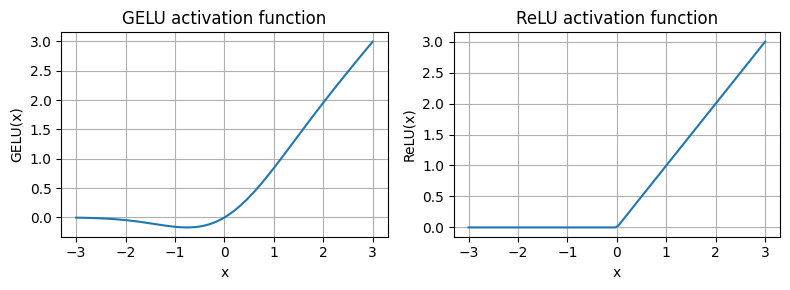

In [159]:
# to get an idea of what this GELU function looks like and how it compares to the ReLU function, let’s plot these functions side by side:

import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

In [160]:
# Listing 4.4 A feed forward neural network module
# ------------------------------------------------

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [161]:
# nitialize a new FeedForward module with a token embedding size of 768 and feed it a batch input with two samples and three tokens each

ffn = FeedForward(GPT_CONFIG_124M)
# Creates sample input with batch dimension 2
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


In [162]:
# isting 4.5 A neural network to illustrate shortcut connections

class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        # Implements five layers
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), 
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), 
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), 
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), 
                          GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), 
                          GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

In [163]:
# Let’s use this code to initialize a neural network without shortcut connections. Each layer will be initialized 
# such that it accepts an example with three input values and returns three output values. The last layer returns
# a single output value:

#layer_sizes = [3, 3, 3, 3, 3, 1]  
#sample_input = torch.tensor([[1., 0., -1.]])
#torch.manual_seed(123)javascript:void(0)
#model_without_shortcut = ExampleDeepNeuralNetwork(
#    layer_sizes, use_shortcut=False
#)


layer_sizes = [3, 3, 3, 3, 3, 1]  
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)


In [164]:
#  implement a function that computes the gradients in the model’s backward pass:

def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [165]:
# use the print_gradients function and apply it to the model without skip connections

print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606


In [166]:
# now instantiate a model with skip connections and see how it compares:

torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.2216978669166565
layers.1.0.weight has gradient mean of 0.20694100856781006
layers.2.0.weight has gradient mean of 0.3289698660373688
layers.3.0.weight has gradient mean of 0.2665731906890869
layers.4.0.weight has gradient mean of 1.3258538246154785


In [167]:
# 4.5 Connecting attention and linear layers in a transformer block
# STOP 11/21/24 1:49 pm 

In [168]:
# Listing 4.6 The transformer block component of GPT
# --------------------------------------------------

# from chapter03 import MultiHeadAttention

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

In [169]:
# Using the GPT_CONFIG_124M dictionary we defined earlier, let’s instantiate a transformer block and feed it some sample data:

torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)


Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


In [170]:
# Listing 4.7 The GPT model architecture implementation
# -----------------------------------------------------

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)

        # The device setting will allow us to train the model on a CPU or GPU, depending on which device the input data sits on.
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [171]:
# Let’s now initialize the 124-million-parameter GPT model using the GPT_CONFIG_ 124M dictionary we pass into the cfg parameter and feed it with the batch 
# text input we previously created:

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.1381,  0.0077, -0.1963,  ..., -0.0222, -0.1060,  0.1717],
         [ 0.3865, -0.8408, -0.6564,  ..., -0.5163,  0.2369, -0.3357],
         [ 0.6989, -0.1829, -0.1631,  ...,  0.1472, -0.6504, -0.0056],
         [-0.4290,  0.1669, -0.1258,  ...,  1.1579,  0.5303, -0.5549]],

        [[ 0.1094, -0.2894, -0.1467,  ..., -0.0557,  0.2911, -0.2824],
         [ 0.0882, -0.3552, -0.3527,  ...,  1.2930,  0.0053,  0.1898],
         [ 0.6091,  0.4702, -0.4094,  ...,  0.7688,  0.3787, -0.1974],
         [-0.0612, -0.0737,  0.4751,  ...,  1.2463, -0.3834,  0.0609]]],
       grad_fn=<UnsafeViewBackward0>)


Book result:

Input batch:
 tensor([[6109,  3626,  6100,   345],
         [6109,  1110,  6622,   257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


In [172]:
# Using the numel() method, short for “number of elements,” we can collect the total number of parameters in the model’s parameter tensors:

total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [173]:
# look at the shapes of the token embedding layer and linear output layer that we initialized on the model via the GPTModel earlier:

print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [174]:
# Let’s remove the output layer parameter count from the total GPT-2 model count according to the weight tying:

total_params_gpt2 = (
    total_params - sum(p.numel()
    for p in model.out_head.parameters())
)
print(f"Number of trainable parameters "
      f"considering weight tying: {total_params_gpt2:,}"
)

Number of trainable parameters considering weight tying: 124,412,160


In [175]:
# compute the memory requirements of the 163 million parameters in our GPTModel object:

total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


In [176]:
# Listing 4.8 A function for the GPT model to generate text

def generate_text_simple(model, idx,
                         max_new_tokens, context_size): 
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [177]:
# Let’s now try out the generate_text_simple function with the "Hello, I am" context as model input. First, we encode the input context into token IDs:

start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)


encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [178]:
# Next, we put the model into .eval() mode. This disables random components like dropout, which are only used during training, 
# and use the generate_text_simple function on the encoded input tensor:

model.eval()
out = generate_text_simple(
    model=model,
    idx=encoded_tensor, 
    max_new_tokens=6, 
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))


Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [179]:
# Using the .decode method of the tokenizer, we can convert the IDs back into text:

decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)


Hello, I am Featureiman Byeswickattribute argue


In [180]:
# STOP: 11/22/24 5:42 PM
# NEXT: 5 Pretraining on unlabeled data


In [181]:
# 5.1.1 Using GPT to generate text
# --------------------------------
# initializing the GPT model that we will later evaluate and train using the GPTModel class and GPT_CONFIG_124M dictionary 

import torch
# from chapter04 import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    # We shorten the context length from 1,024 to 256 tokens.
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    # It’s possible and common to set dropout to 0.
    "drop_rate": 0.1,
    "qkv_bias": False
}
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [182]:
# Listing 5.1 Utility functions for text to token ID conversion
# -------------------------------------------------------------

import tiktoken
# from chapter04 import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    # unsqueeze(0) adds the batch dimension
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    # Removes batch dimension
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))


Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


In [183]:
# two input examples

inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

In [184]:
targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107, 588, 11311]])  #  " really like chocolate"]

In [185]:
# feed the inputs into the model to calculate logits vectors for the two input examples, each comprising three tokens. 
# Then we apply the softmax function to transform these logits into probability scores (probas; figure 5.4, step 2):

# Disables gradient tracking since we are not training yet
with torch.no_grad():
    logits = model(inputs)
# Probability of each token in vocabulary
probas = torch.softmax(logits, dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


In [186]:
#  applying the argmax function to the probability scores to obtain the corresponding token ID

token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)


Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [187]:
# converts the token IDs back into text:

print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:"
      f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")


Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [188]:
# For each of the two input texts, we can print the initial softmax probability scores corresponding to the target tokens using the following code:

text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([    0.0001,     0.0000,     0.0000])
Text 2: tensor([    0.0000,     0.0001,     0.0000])


Bool Results:

Text 1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])

In [189]:
# calculate the loss for the probability scores of the two example batches, target_probas_1 and target_probas_2.

log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [190]:
# combine these log probabilities into a single score by computing the average

avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


In [191]:
# The goal is to get the average log probability as close to 0 as possible by updating the model’s weights as part of the 
# training process. However, in deep learning, the common practice isn’t to push the average log probability up to 0 but 
# rather to bring the negative average log probability down to 0. The negative average log probability is simply the 
# average log probability multiplied by –1, which corresponds to step 6 in figure 5.7:

neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


In [192]:
# recall the shape of the logits and target tensors:

print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [193]:
# For the cross_entropy loss function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:

logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [194]:
# Previously, we applied the softmax function, selected the probability scores corresponding to the target IDs, and computed 
# the negative average log probabilities. PyTorch’s cross_entropy function will take care of all these steps for us:

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


In [195]:
# code loads the “The Verdict” short story:

with open("E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\the-verdict.txt", "r", encoding="utf-8") as f:
    text_data = f.read()


In [196]:
# check the number of characters and tokens in the dataset

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [197]:
# To implement the data splitting and loading, we first define a train_ratio to use 90% of the data for training 
# and the remaining 10% as validation data for model evaluation during training:

train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [198]:
# now create the respective data loader reusing the create_dataloader_v1 code 

# from chapter02 import create_dataloader_v1
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [199]:
# As an optional check, we can iterate through the data loaders to ensure that they were created correctly:

print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [200]:
# implement a utility function to calculate the cross entropy loss of a given batch returned via the training and validation loader:

def calc_loss_batch(input_batch, target_batch, model, device):
    # The transfer to a given device allows us to transfer the data to a GPU.
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)      
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

In [201]:
# Listing 5.2 Function to compute the training and validation loss
# ----------------------------------------------------------------
# implement the following calc_loss_loader function that computes the loss over all the batches sampled by a given data loader.

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        # Iteratives over all batches if no fixed num_batches is specified
        num_batches = len(data_loader)
    else:
        # Reduces the number of batches to match the total number of batches in the data loader 
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            # Sums loss for each batch
            total_loss += loss.item()
        else:
            break
    # Averages the loss over all batches
    return total_loss / num_batches


In [202]:
# Let’s now see this calc_loss_loader function in action, applying it to the training and validation set loaders:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# If you have a machine with a CUDA-supported GPU, the LLM will train on the GPU without making any changes to the code.
model.to(device)
# Disables gradient tracking for efficiency because we are not training yet
with torch.no_grad():
    # Via the “device” setting, we ensure the data is loaded onto the same device as the LLM model.
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)


Training loss: 10.987583584255642
Validation loss: 10.98110580444336


STOP: 11/23/24  12:14 PM
5.2 Training an LLM


In [203]:
# Listing 5.3 The main function for pretraining LLMs
# --------------------------------------------------

def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):

    # Initializes lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Starts the main training loop
    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            # Resets loss gradients from the previous batch iteration
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            # Calculates loss gradients
            loss.backward()
            # Updates model weights using loss gradients
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        # Prints a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen


In [204]:
# The evaluate_model function corresponds to step 7 in figure 5.11. It prints the training and validation set losses after each 
# model update so we can evaluate whether the training improves the model. More specifically, the evaluate_model function calculates 
# the loss over the training and validation set while ensuring the model is in evaluation mode with gradient tracking and dropout 
# disabled when calculating the loss over the training and validation sets:

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    # Dropout is disabled during evaluation for stable, reproducible results.
    model.eval()
    # Disables gradient tracking, which is not required during evaluation, to reduce the computational overhead
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss


In [205]:
# Similar to evaluate_model, the generate_and_print_sample function is a convenience function that we use to track whether the model 
# improves during the training. In particular, the generate_and_print_sample function takes a text snippet (start_context) as input, 
# converts it into token IDs, and feeds it to the LLM to generate a text sample using the generate_text_simple function we used earlier:

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)

    # Compact print format
    print(decoded_text.replace("\n", " "))
    model.train()


In [206]:
# Let’s see this all in action by training a GPTModel instance for 10 epochs using an AdamW optimizer and the 
# train_model_simple function we defined earlier: 

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    # The .parameters() method returns all trainable weight parameters of the model.
     model.parameters(),
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.783, Val loss 9.927
Ep 1 (Step 000005): Train loss 7.985, Val loss 8.335
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.753, Val loss 7.048
Ep 2 (Step 000015): Train loss 6.114, Val loss 6.573
Every effort moves you, and,, and, and,,,,, and, and,,,,,,,,,,,,,, and,,,, and,, and,,,,, and,,,,,,
Ep 3 (Step 000020): Train loss 5.525, Val loss 6.490
Ep 3 (Step 000025): Train loss 5.324, Val loss 6.387
Every effort moves you, and to the picture.                      "I, and the of the of the's the honour, and, and I had been, and I
Ep 4 (Step 000030): Train loss 4.761, Val loss 6.360
Ep 4 (Step 000035): Train loss 4.461, Val loss 6.258
Every effort moves you of the to the picture--as of the picture--as I had been " it was his " I was the     "I was his I had been the his pictures--and it the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 3.833, Val loss 6.196
Every effort moves yo

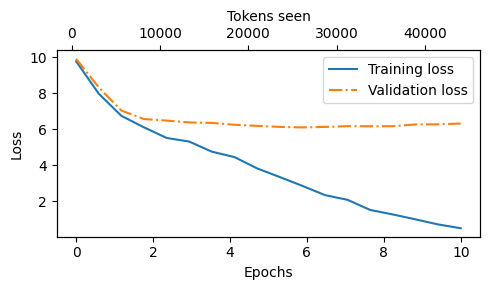

In [207]:
# create a simple plot that shows the training and validation set losses side by side:

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    # Creates a second x-axis that shares the same y-axis
    ax2 = ax1.twiny()
    # Invisible plot for aligning ticks
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [208]:
# We begin by transferring the model back from the GPU to the CPU since inference with a relatively small model does not require a GPU. 
# Also, after training, we put the model into evaluation mode to turn off random components such as dropout:

model.to("cpu")
model.eval()


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [209]:
# Next, we plug the GPTModel instance (model) into the generate_text_simple function, which uses the LLM to generate one token at a time:

tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [210]:
# To illustrate the probabilistic sampling with a concrete example, let’s briefly discuss the next-token generation process 
# using a very small vocabulary for illustration purposes:

vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 
inverse_vocab = {v: k for k, v in vocab.items()}

In [211]:
# Next, assume the LLM is given the start context "every effort moves you" and generates the following next-token logits:

next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [212]:
# As discussed in chapter 4, inside generate_text_simple, we convert the logits into probabilities via the 
# softmax function and obtain the token ID corresponding to the generated token via the argmax function, which 
# we can then map back into text via the inverse vocabulary:

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


In [213]:
# To implement a probabilistic sampling process, we can now replace argmax with the multinomial function in PyTorch:

torch.manual_seed(123) 
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

toward


Author:
The printed output is "forward" just like before. 

In [214]:
# let’s implement a function that repeats this sampling 1,000 times:

def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item()
             for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

71 x closer
2 x every
0 x effort
544 x forward
2 x inches
1 x moves
0 x pizza
376 x toward
4 x you


Authot:

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward

In [215]:
# We can further control the distribution and selection process via a concept called temperature scaling. 
# Temperature scaling is just a fancy description for dividing the logits by a number greater than 0:

def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

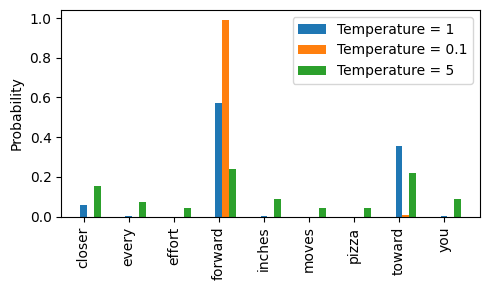

In [216]:
# Temperatures greater than 1 result in more uniformly distributed token probabilities, and temperatures smaller than 1 
# will result in more confident (sharper or more peaky) distributions. Let’s illustrate this by plotting the original 
# probabilities alongside probabilities scaled with different temperature values:

# Original, lower, and higher confidence
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T)
                for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], 
                   bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [217]:
# STOP: 11/24/24 5:59 PM
# NEXT: 5.3.2 Top-k sampling

In [218]:
#  implement the top-k procedure as follows, starting with the selection of the tokens with the largest logit values:

top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [219]:
# Subsequently, we apply PyTorch’s where function to set the logit values of tokens that are below the lowest logit value 
# within our top-three selection to negative infinity (-inf): 

new_logits = torch.where(
    # Identifies logits less than the minimum in the top 3
    condition=next_token_logits < top_logits[-1],
    # Assigns –inf to these lower logits
    input=torch.tensor(float('-inf')),
    # Retains the original logits for all other tokens
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [220]:
# apply the softmax function to turn these into next-token probabilities:

topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [221]:
# combine temperature sampling and top-k sampling to modify the generate_ text_simple function we used to generate 
# text via the LLM earlier, creating a new generate function.

# Listing 5.4 A modified text generation function with more diversity

def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    # The for loop is the same as before: gets logits and only focuses on the last time step.
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        # Filters logits with top_k sampling
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )
        # Applies temperature scaling
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        # Carries out greedy next-token selection as before when temperature scaling is disabled
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        # Stops generating early if end-of-sequence token is encountered
        if idx_next == eos_id:
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [222]:
# Let’s now see this new generate function in action:

torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

'''
Author:

Output text:
 Every effort moves you stand to work on surprise, a one of us had gone
 with random-
'''

Output text:
 Every effort moves you know began to my surprise, a little it was the
"Ah enough


'\nAuthor:\n\nOutput text:\n Every effort moves you stand to work on surprise, a one of us had gone\n with random-\n'

In [223]:
# saving a PyTorch model is relatively straightforward. The recommended way is to save a model’s state_dict, 
# a dictionary mapping each layer to its parameters, using the torch.save function:

torch.save(model.state_dict(), "E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\model.pth")

In [224]:
# after saving the model weights via the state_dict, we can load the model weights into a new GPTModel model instance:

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\model.pth", map_location=device))
model.eval()

C:\Users\gcart\AppData\Local\Temp\ipykernel_8344\996197735.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("E:\\technical_documents_2024

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [225]:
#  Using torch.save, we can save both the model and optimizer state_dict contents:

torch.save({
    "E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\model_state_dict": model.state_dict(),
    "E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\optimizer_state_dict": optimizer.state_dict(),
    }, 
    "E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\model_and_optimizer.pth"
)

In [226]:
# we can restore the model and optimizer states by first loading the saved data via torch.load and then using the load_state_dict method:

checkpoint = torch.load("E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\optimizer_state_dict"])
model.train();

C:\Users\gcart\AppData\Local\Temp\ipykernel_8344\921053777.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("E:\\technical_documents_20241218\\boo

In [227]:
# Note that OpenAI originally saved the GPT-2 weights via TensorFlow, which we have to install to load the weights in Python. 
# The following code will use a progress bar tool called tqdm to track the download process, which we also have to install.
# You can install these libraries by executing the following command in your terminal:

!pip install tensorflow>=2.15.0  tqdm>=4.66


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [228]:
# download the gpt_download.py Python module directly from this chapter’s online repository:

import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x145c9fcdc50>)

In [229]:
# lets find where it saved the file

import os

# Get the current working directory
cwd = os.getcwd()
print(cwd)

# C:\Users\gcart

# then copy to E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\

C:\Users\gcart


In [230]:
# change working directory

os.chdir('E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\')
print(os.getcwd())

E:\technical_documents_20241218\book_reviews\manning\build_llm_from_scratch


In [231]:
# now import the download_and_load_gpt2 function from the gpt_download .py file as follows, which will load the GPT-2 architecture settings (settings) and weight parameters (params) 
# into our Python session:

from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [232]:
# inspect the contents of settings and params:

print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [233]:
# we can inspect these weight tensors by printing the whole dictionary via print(params) or by selecting individual tensors via the respective dictionary keys, 
# for example, the embedding layer weights:

print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

'''
Author output:
[[-0.11010301 ... -0.1363697   0.01506208   0.04531523]
 [ 0.04034033 ...  0.08605453  0.00253983   0.04318958]
 [-0.12746179  ...  0.08991534 -0.12972379 -0.08785918]
 ...
 [-0.04453601 ...   0.10435229  0.09783269 -0.06952604]
 [ 0.1860082  ...  -0.09625227  0.07847701 -0.02245961]
 [ 0.05135201 ...   0.00704835  0.15519823  0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)
'''

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


'\nAuthor output:\n[[-0.11010301 ... -0.1363697   0.01506208   0.04531523]\n [ 0.04034033 ...  0.08605453  0.00253983   0.04318958]\n [-0.12746179  ...  0.08991534 -0.12972379 -0.08785918]\n ...\n [-0.04453601 ...   0.10435229  0.09783269 -0.06952604]\n [ 0.1860082  ...  -0.09625227  0.07847701 -0.02245961]\n [ 0.05135201 ...   0.00704835  0.15519823  0.12067825]]\nToken embedding weight tensor dimensions: (50257, 768)\n'

In [234]:
# After loading the GPT-2 model weights into Python, we still need to transfer them from the settings and params dictionaries 
# into our GPTModel instance. First, we create a dictionary that lists the differences between the different GPT model sizes in figure 5.17:

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [235]:
# Suppose we are interested in loading the smallest model, "gpt2-small (124M)". We can use the corresponding settings from the model_configs table to update our full-length GPT_CONFIG_124M 
# we defined and used earlier:

model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

In [236]:
# Careful readers may remember that we used a 256-token length earlier, but the original GPT-2 models from OpenAI were trained with 
# a 1,024-token length, so we have to update the NEW_CONFIG accordingly:

NEW_CONFIG.update({"context_length": 1024})

In [237]:
# Also, OpenAI used bias vectors in the multi-head attention module’s linear layers to implement the query, key, and value 
# matrix computations. Bias vectors are not commonly used in LLMs anymore as they don’t improve the modeling performance 
# and are thus unnecessary. However, since we are working with pretrained weights, we need to match the settings for 
# consistency and enable these bias vectors:

NEW_CONFIG.update({"qkv_bias": True})

In [238]:
# We can now use the updated NEW_CONFIG dictionary to initialize a new GPTModel instance:

gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [239]:
# By default, the GPTModel instance is initialized with random weights for pretraining. The last step to using OpenAI’s 
# model weights is to override these random weights with the weights we loaded into the params dictionary. For this, we
# will first define a small assign utility function that checks whether two tensors or arrays (left and right) have the 
# same dimensions or shape and returns the right tensor as trainable PyTorch parameters:

def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
                          "Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))

In [240]:
# Next, we define a load_weights_into_gpt function that loads the weights from the params dictionary into a GPTModel instance gpt.

# Listing 5.5 Loading OpenAI weights into our GPT model code
# ----------------------------------------------------------

import numpy as np

# Sets the model’s positional and token embedding weights to those specified in params.
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    # Iterates over each transformer block in the model
    for b in range(len(params["blocks"])):
        # The np.split function is used to divide the attention and bias weights into 
        # three equal parts for the query, key, and value components.
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    # The original GPT-2 model by OpenAI reused the token embedding weights in the output layer 
    # to reduce the total number of parameters, which is a concept known as weight tying.
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


In [241]:
# Let’s now try the load_weights_into_gpt out in practice and load the OpenAI model weights into our GPTModel instance gpt:

load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [242]:
# If the model is loaded correctly, we can now use it to generate new text using our previous generate function:

torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

'''
Author output:
Output text:
 Every effort moves you toward finding an ideal new way to practice something!
What makes us want to be on top of that?
'''

Output text:
 Every effort moves you toward an equal share for each vote plus half. Inequality is often not an accurate representation of human worth; to know the


'\nAuthor output:\nOutput text:\n Every effort moves you toward finding an ideal new way to practice something!\nWhat makes us want to be on top of that?\n'

In [243]:
# 6 Fine-tuning for classification
# ================================

In [244]:
# Listing 6.1 Downloading and unzipping the dataset
# -------------------------------------------------

import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\sms_spam_collection.zip"
extracted_path = "E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

In [245]:
def download_and_unzip_spam_data(
        url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download "
              "and extraction."
        )
        return

    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

In [246]:
download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

E:\technical_documents_20241218\book_reviews\manning\build_llm_from_scratch\sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [247]:
# NOTE: ISSUES ENCOUNTERED USING download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
# SO i DOWNLOADED AND UNZIPPED MANUALLY

In [249]:
# load it into a pandas DataFrame as follows:load it into a pandas DataFrame as follows:

'''
version using download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
import pandas as pd
df = pd.read_csv(
    data_file_path, sep="\t", header=None, names=["Label", "Text"]
)
df
'''
# version using manual download and unzipping
import pandas as pd

data_file_path = "E:\\technical_documents_20241218\\book_reviews\\manning\\build_llm_from_scratch\\sms_spam_collection\\SMSSpamCollection.tsv"

df = pd.read_csv(
    data_file_path, sep="\t", header=None, names=["Label", "Text"]
)
df


,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [250]:
# examine the class label distribution:

print(df["Label"].value_counts())

ham     4825
spam     747
Name: Label, dtype: int64


In [251]:
# Listing 6.2 Creating a balanced dataset
# ---------------------------------------

def create_balanced_dataset(df):
    # Counts the instances of “spam”
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df[df["Label"] == "ham"].sample(
        num_spam, random_state=123
    # Randomly samples “ham” instances to match the number of “spam” instances
    )
    balanced_df = pd.concat([
        ham_subset, df[df["Label"] == "spam"]
    # Combines ham subset with “spam”
    ])
    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

ham     747
spam    747
Name: Label, dtype: int64


In [252]:
# convert the “string” class labels "ham" and "spam" into integer class labels 0 and 1, respectively:

balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [253]:
# create a random_split function to split the dataset into three parts: 70% for training, 10% for validation,
# and 20% for testing. (These ratios are common in machine learning to train, adjust, and evaluate models.)

# Listing 6.3 Splitting the dataset
# ---------------------------------

def random_split(df, train_frac, validation_frac):

    df = df.sample(
        frac=1, random_state=123
    # Shuffles the entire DataFrame
    ).reset_index(drop=True)
    # Calculates split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Splits the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(
    # Splits the DataFrame
    balanced_df, 0.7, 0.1)

In [255]:
# Let’s save the dataset as CSV (comma-separated value) files so we can reuse it later:

my_base_path = r'E:\technical_documents_20241218\book_reviews\manning\build_llm_from_scratch'

train_df.to_csv(f"{my_base_path}\\train.csv", index=None)
validation_df.to_csv(f"{my_base_path}\\validation.csv", index=None)
test_df.to_csv(f"{my_base_path}\\test.csv", index=None)



In [256]:
# double-check whether the token ID is correct by encoding the "<|endoftext|>" using the GPT-2 
# tokenizer from the tiktoken package that we used previously:

import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [257]:
# Listing 6.4 Setting up a Pytorch Dataset class
# ----------------------------------------------

import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None,
                 pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pretokenizes texts
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length

            # Truncates sequences if they are longer than max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        
        # Pads sequences to the longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] * 
            (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]


    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

In [258]:
# The SpamDataset class loads data from the CSV files we created earlier, tokenizes the text using the GPT-2 tokenizer
# from tiktoken, and allows us to pad or truncate the sequences to a uniform length determined by either the longest 
# sequence or a predefined maximum length. This ensures each input tensor is of the same size, which is necessary to 
# create the batches in the training data loader we implement next:

train_dataset = SpamDataset(
    csv_file=f"{my_base_path}\\train.csv",
    max_length=None,
    tokenizer=tokenizer
)

In [259]:
# to see the number of tokens in the longest sequence, you can use the following code:

print(train_dataset.max_length)

120


In [260]:
# Next, we pad the validation and test sets to match the length of the longest training sequence. 

val_dataset = SpamDataset(
    csv_file=f"{my_base_path}\\validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file=f"{my_base_path}\\test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

In [261]:
# Listing 6.5 Creating PyTorch data loaders

from torch.utils.data import DataLoader

# This setting ensures compatibility with most computers.
num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [262]:
# To ensure that the data loaders are working and are, indeed, returning batches of the expected size, we iterate over 
# the training loader and then print the tensor dimensions of the last batch:

for input_batch, target_batch in train_loader:
    pass
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [263]:
# to get an idea of the dataset size, let’s print the total number of batches in each dataset:

print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


In [264]:
# To begin the model preparation process, we employ the same configurations we used to pretrain unlabeled data:

CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
    # Vocabulary size
    "vocab_size": 50257,
    # Context length
    "context_length": 1024,
    # Dropout rate
    "drop_rate": 0.0,
    # Query-key-value bias
    "qkv_bias": True
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [265]:
# Next, we import the download_and_load_gpt2 function from the gpt_download.py file and reuse the GPTModel class and 
# load_weights_into_gpt function from pretraining (see chapter 5) to load the downloaded weights into the GPT model.

from gpt_download import download_and_load_gpt2
# from chapter05 import GPTModel, load_weights_into_gpt
# import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [266]:
# After loading the model weights into the GPTModel, we reuse the text generation utility function from chapters 4 and 5 to 
# ensure that the model generates coherent text:

# from chapter04 import generate_text_simple
# from chapter05 import text_to_token_ids, token_ids_to_text

text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

"""
Author:
Every effort moves you forward.
The first step is to understand the importance of your work
"""

Every effort moves you forward.

The first step is to understand the importance of your work


'\nAuthor:\nEvery effort moves you forward.\nThe first step is to understand the importance of your work\n'

In [269]:
# Before we start fine-tuning the model as a spam classifier, let’s see whether the model already classifies spam messages 
# by prompting it with instructions:

text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))


"""
Author:

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner
you have been specially selected to receive $1000 cash 
or a $2000 award.'
The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner

"""

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


"\nAuthor:\n\nIs the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner\nyou have been specially selected to receive $1000 cash \nor a $2000 award.'\nThe following text 'spam'? Answer with 'yes' or 'no': 'You are a winner\n\n"

In [268]:
# STOP -- 12/10/24 8:21 pm
# CONTINUE @ 6.5 Adding a classification head

In [ ]:
# STOP -- 12/21/24 7:58 pm
# CONTINUE @ 6.5 Adding a classification head

In [273]:
# Before we attempt the modification shown in figure 6.9, let’s print the model architecture via print(model):

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (2): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (3): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (4): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (5): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (6): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (7): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (8): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (9): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (10): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (11): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
  )
  (final_norm): LayerNorm()
  (out_head): Linear(in_features=768, out_features=50257, bias=False)
)



SyntaxError: invalid syntax (3425229007.py, line 5)

In [ ]:
# STOP -- 12/21/24 7:58 pm
# CONTINUE @ 6.5 Adding a classification head

In [ ]:
# STOP -- 12/22/24 5:34 pm
# Last error "SyntaxError: invalid syntax" could not be resolved.
# For sake of time, discontinue running of book code.